## Sensitivity analysis

### Flood intensities are categorized as follows: strong = 1.0, medium = 0.50, and low = 0.25. Tourism is constant at 0.50 across all FTb scenarios.


--- Running Baseline ---
The values converged in the 5 state (e <= 0.001)

--- Running Flood with Improvement ---
The values converged in the 6 state (e <= 0.001)
Final Activation Values for Flood with Improvement:
 Pro-Mit           1.000000
Monitoring        0.404319
Con & Res         0.784191
Budget            0.287912
OUV               0.731545
Unfenced          1.000000
OGE               0.250000
Usage             0.000000
Preservation      0.936888
Flooding          0.637031
Wind              0.100000
 landscape        0.527424
Excavation        0.000000
Local income      0.000000
Sustainability    0.000000
Tourism           0.000000
ComV              0.200000
Precipitations    1.000000
Abandonment       0.000000
Erosion           0.753259
Accessibility     0.279001
ResDev            0.000000
OG                0.500000
US                0.000000
Wild plants       0.000000
Temperature       0.100000
LA                0.431977
HR                0.100000
TF                0.250000


/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

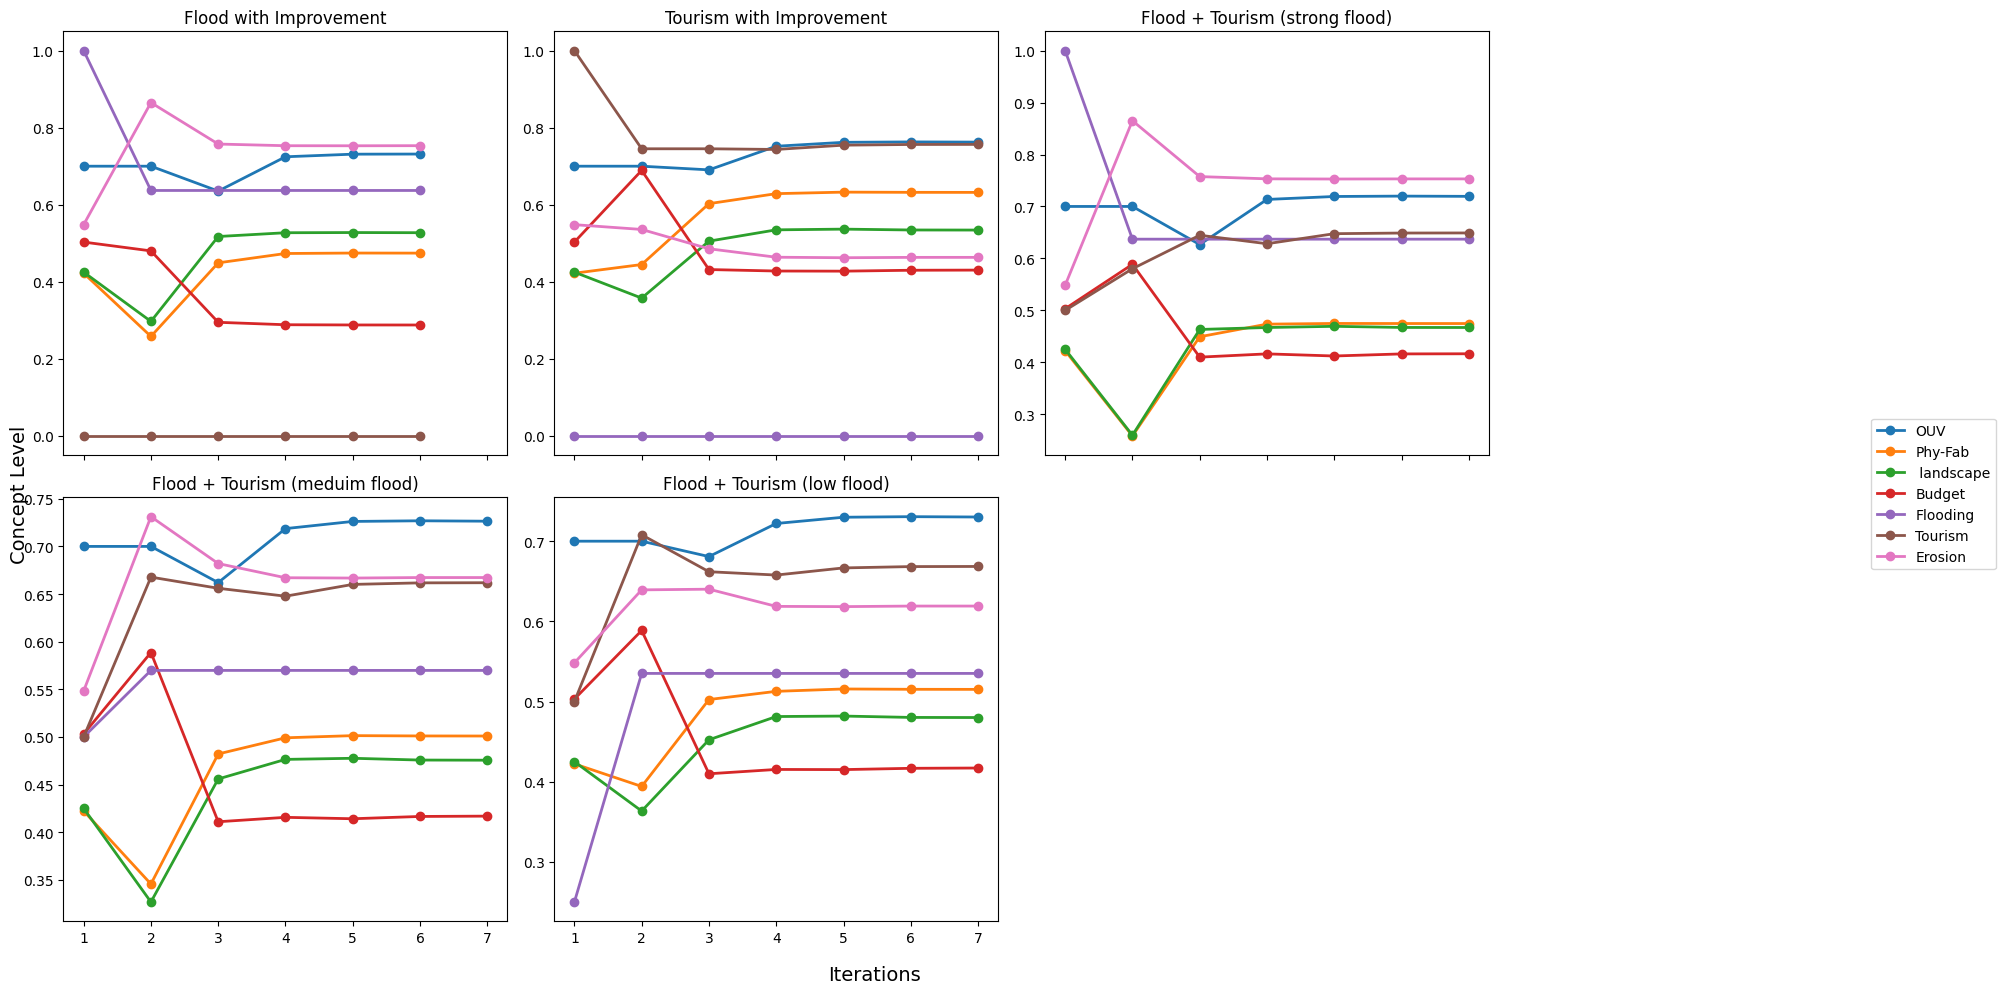

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from fcmpy import FcmSimulator
import os

# --- File paths ---
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_folder = "Analysis and output folders"
os.makedirs(output_folder, exist_ok=True)

# --- Load FCM adjacency matrix ---
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# --- Load concept labels ---
labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# --- Load initial values ---
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    if 'Concept ID' not in df.columns or 'Initial Value' not in df.columns:
        raise ValueError("CSV must have 'Concept ID' and 'Initial Value'")
    return {
        concept_label_map.get(cid, cid): float(df.loc[df['Concept ID'] == cid, 'Initial Value'].values[0])
        if cid in df['Concept ID'].values else 0.0
        for cid in concept_ids
    }

init_state = get_initial_values()
sim = FcmSimulator()

# --- Simulation function ---
def simulate_fcm(initial_state, weight_matrix, iterations=20):
    mod_matrix = weight_matrix.copy()
    inactive = [c for c, v in initial_state.items() if float(v) == 0.0]
    for c in inactive:
        if c in concept_labels:
            idx = concept_labels.index(c)
            mod_matrix[:, idx] = 0
            mod_matrix[idx, :] = 0

    result = sim.simulate(
        initial_state=initial_state,
        weight_matrix=mod_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=iterations,
        l=1
    )
    return result

# --- Run Baseline ---
print("\n--- Running Baseline ---")
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concept_labels)
last_values = {k: float(v) for k, v in baseline_df.iloc[-1].to_dict().items()}

# --- Define interventions ---
def apply_intervention(name, base_state):
    state = base_state.copy()
    if name == "flood_improvement":
        state.update({
            concept_label_map['C15']: 1.0,
            concept_label_map['C11']: 1.0,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })
    elif name == "tourism_improvement":
        state.update({
            concept_label_map['C40']: 1.0,
            concept_label_map['C21']: 0.1,
            concept_label_map['C28']: 0.1
        })
    elif name == "flood_tourism_improvement_1.0":
        state.update({
            concept_label_map['C15']: 1.0,
            concept_label_map['C11']: 1.0,
            concept_label_map['C40']: 0.5,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })
    elif name == "flood_tourism_improvement_0.5":
        state.update({
            concept_label_map['C15']: 0.5,
            concept_label_map['C11']: 0.5,
            concept_label_map['C40']: 0.5,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })
    elif name == "flood_tourism_improvement_0.25":
        state.update({
            concept_label_map['C15']: 0.25,
            concept_label_map['C11']: 0.25,
            concept_label_map['C40']: 0.5,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })
    return state

# --- Scenarios ---
scenarios = {
    "Baseline": last_values,
    "Flood with Improvement": apply_intervention("flood_improvement", last_values),
    "Tourism with Improvement": apply_intervention("tourism_improvement", last_values),
    "Flood + Tourism (strong flood)": apply_intervention("flood_tourism_improvement_1.0", last_values),
    "Flood + Tourism (meduim flood)": apply_intervention("flood_tourism_improvement_0.5", last_values),
    "Flood + Tourism (low flood)": apply_intervention("flood_tourism_improvement_0.25", last_values)
}

# --- Target Concepts ---
target_concepts = ["C1", "C2", "C3", "C7", "C15", "C40", "C8"]
target_labels = [concept_label_map[cid] for cid in target_concepts]

# --- Run and Plot (2x3 grid, excluding baseline) ---
scenario_results = {}

# Remove baseline for plotting
plot_scenarios = {k: v for k, v in scenarios.items() if k != "Baseline"}

n_scenarios = len(plot_scenarios)
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharex=True)

axes = axes.flatten()

for ax, (name, state) in zip(axes, plot_scenarios.items()):
    print(f"\n--- Running {name} ---")
    result = simulate_fcm(state, weight_matrix)
    df_result = pd.DataFrame(result, columns=concept_labels)
    scenario_results[name] = df_result

    # Print final values
    print(f"Final Activation Values for {name}:\n", df_result.iloc[-1])

    # Plot evolution of target concepts
    x_values = range(1, len(df_result) + 1)
    for cid, label in zip(target_concepts, target_labels):
        ax.plot(x_values, df_result[label], label=label, marker='o', linewidth=2)
    ax.set_title(name, fontsize=12)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(False)

# Remove unused subplot if any
if n_scenarios < len(axes):
    for ax in axes[n_scenarios:]:
        ax.axis("off")

# Global axis labels (clean placement outside subplots)
fig.supxlabel("Iterations", fontsize=14)
fig.supylabel("Concept Level", fontsize=14)

# One global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc="center left")

# Adjust layout so labels + legend fit
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(os.path.join(output_folder, "all_scenarios_grid.png"), dpi=300)
plt.show()


/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 6 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


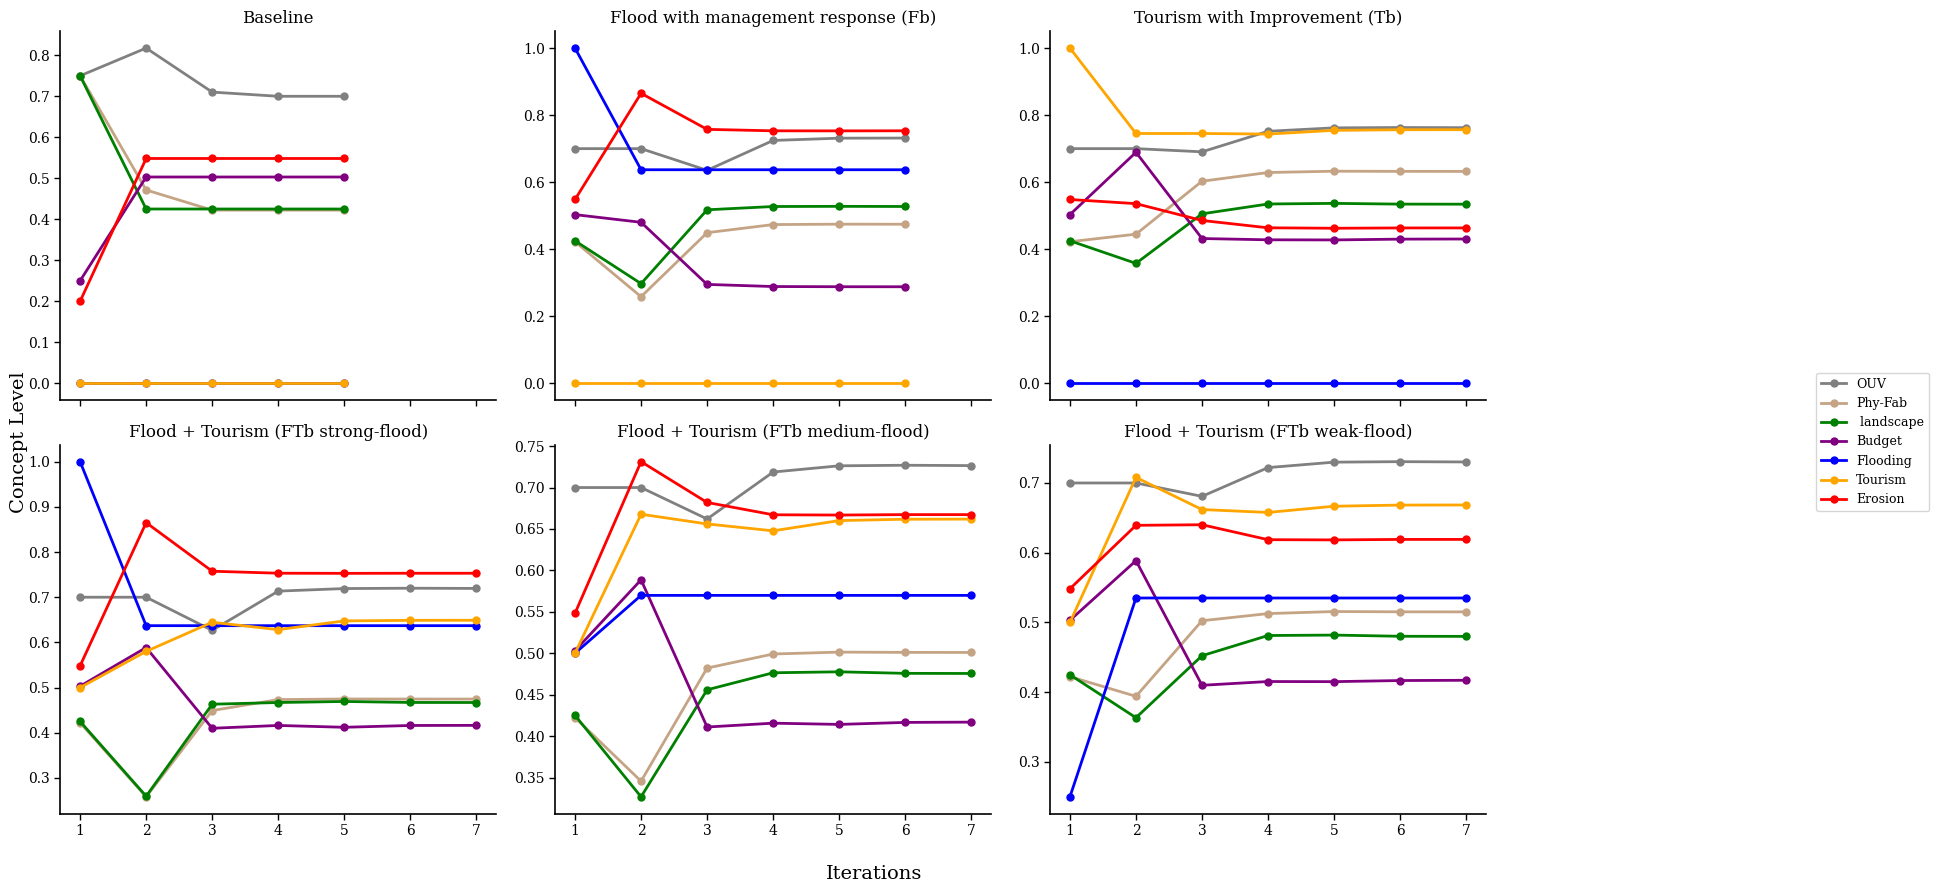

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from fcmpy import FcmSimulator
import os

# --- File paths ---
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_folder = "Appendices"
os.makedirs(output_folder, exist_ok=True)

# --- Load FCM adjacency matrix ---
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# --- Load concept labels ---
labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# --- Load initial values ---
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept_label_map.get(cid, cid): float(df.loc[df['Concept ID'] == cid, 'Initial Value'].values[0])
        if cid in df['Concept ID'].values else 0.0
        for cid in concept_ids
    }

init_state = get_initial_values()
sim = FcmSimulator()

# --- Simulation function ---
def simulate_fcm(initial_state, weight_matrix, iterations=20):
    mod_matrix = weight_matrix.copy()
    inactive = [c for c, v in initial_state.items() if float(v) == 0.0]
    for c in inactive:
        if c in concept_labels:
            idx = concept_labels.index(c)
            mod_matrix[:, idx] = 0
            mod_matrix[idx, :] = 0

    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=mod_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=iterations,
        l=1
    )

# --- Run Baseline correctly ---
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concept_labels)

# Get steady-state for interventions
last_values = {k: float(v) for k, v in baseline_df.iloc[-1].to_dict().items()}

# --- Interventions ---
def apply_intervention(name, base_state):
    state = base_state.copy()
    if name == "flood_improvement":
        state.update({concept_label_map['C15']: 1.0, concept_label_map['C11']: 1.0,
                      concept_label_map['C21']: 0.1, concept_label_map['C27']: 1.0,
                      concept_label_map['C28']: 0.1})
    elif name == "tourism_improvement":
        state.update({concept_label_map['C40']: 1.0,
                      concept_label_map['C21']: 0.1, concept_label_map['C28']: 0.1})
    elif name == "flood_tourism_improvement_1.0":
        state.update({concept_label_map['C15']: 1.0, concept_label_map['C11']: 1.0,
                      concept_label_map['C40']: 0.5, concept_label_map['C21']: 0.1,
                      concept_label_map['C27']: 1.0, concept_label_map['C28']: 0.1})
    elif name == "flood_tourism_improvement_0.5":
        state.update({concept_label_map['C15']: 0.5, concept_label_map['C11']: 0.5,
                      concept_label_map['C40']: 0.5, concept_label_map['C21']: 0.1,
                      concept_label_map['C27']: 1.0, concept_label_map['C28']: 0.1})
    elif name == "flood_tourism_improvement_0.25":
        state.update({concept_label_map['C15']: 0.25, concept_label_map['C11']: 0.25,
                      concept_label_map['C40']: 0.5, concept_label_map['C21']: 0.1,
                      concept_label_map['C27']: 1.0, concept_label_map['C28']: 0.1})
    return state

# --- Scenarios (NO baseline here) ---
scenarios = {
    "Flood with management response (Fb)": apply_intervention("flood_improvement", last_values),
    "Tourism with management response (Tb)": apply_intervention("tourism_improvement", last_values),
    "Flood + Tourism (FTb strong-flood)": apply_intervention("flood_tourism_improvement_1.0", last_values),
    "Flood + Tourism (FTb medium-flood)": apply_intervention("flood_tourism_improvement_0.5", last_values),
    "Flood + Tourism (FTb weak-flood)": apply_intervention("flood_tourism_improvement_0.25", last_values)
}

# --- Target Concepts ---
target_concepts = ["C1", "C2", "C3", "C7", "C15", "C40", "C8"]
target_labels = [concept_label_map[cid] for cid in target_concepts]

# --- Colors ---
concept_colors = {
    "C1": "gray",
    "C2": "#C4A484",
    "C3": "green",
    "C7": "purple",
    "C8": "red",
    "C15": "blue",
    "C40": "orange"
}

# --- Style ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "lines.markersize": 5
})

# --- Plotting ---
all_names = ["Baseline"] + list(scenarios.keys())
n = len(all_names)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4.5*rows), sharex=True)
axes = axes.flatten()

# ---- BASELINE (correct) ----
ax = axes[0]
x_values = range(1, len(baseline_df) + 1)

for cid, label in zip(target_concepts, target_labels):
    ax.plot(x_values, baseline_df[label],
            marker='o',
            color=concept_colors.get(cid, "black"),
            label=label)

ax.set_title("Baseline")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(direction='out', length=4, width=1)
ax.grid(False)

# ---- SCENARIOS ----
scenario_results = {}

for i, (name, state) in enumerate(scenarios.items(), start=1):
    ax = axes[i]

    result = simulate_fcm(state, weight_matrix)
    df_result = pd.DataFrame(result, columns=concept_labels)
    scenario_results[name] = df_result

    x_values = range(1, len(df_result) + 1)

    for cid, label in zip(target_concepts, target_labels):
        ax.plot(x_values, df_result[label],
                marker='o',
                color=concept_colors.get(cid, "black"))

    ax.set_title(name)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(direction='out', length=4, width=1)
    ax.grid(False)

# Remove empty axes
for ax in axes[n:]:
    ax.axis("off")

# Global labels
fig.supxlabel("Iterations", fontsize=14)
fig.supylabel("Concept Level", fontsize=14)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc="center left")

plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save outputs
png_path = os.path.join(output_folder, "Sensitivity analysis_with_Baseline.png")
pdf_path = os.path.join(output_folder, "Sensitivity analysis_with_Baseline.pdf")

plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

plt.show()

## Comparison of five scenarios: Flood (Fb), Tourism (Tb), and Combined (FTb) with management responses under different flood intensities (weak, medium, strong)

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 2 state (e <= 0.001)
The values converged in the 6 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


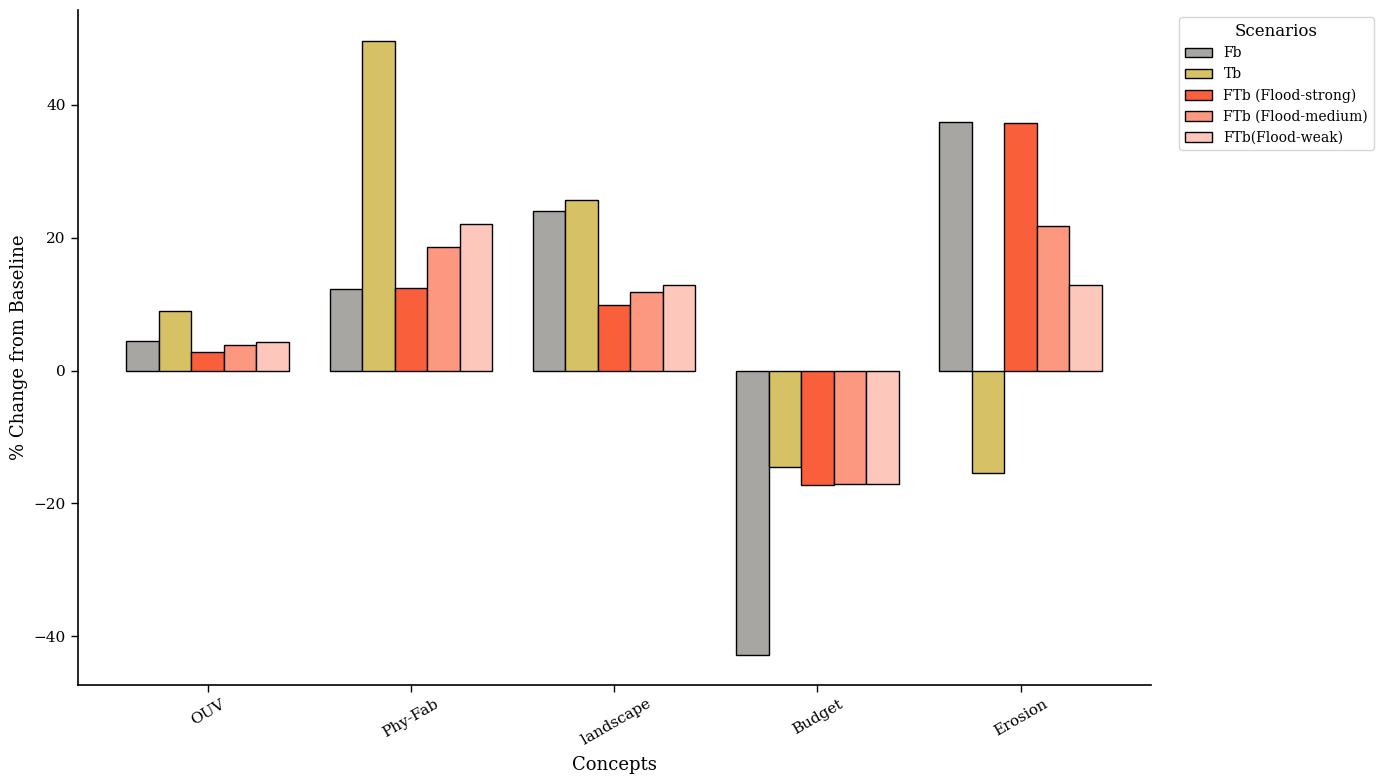


Final Activation Values Table:
                          OUV   Phy-Fab   landscape    Budget   Erosion
Baseline            0.700012  0.422308    0.425048  0.503125  0.548287
Fb                  0.731545  0.474448    0.527424  0.287912  0.753259
Tb                  0.762543  0.632038    0.534282  0.430384  0.463434
FTb (Flood-strong)  0.719455  0.474624    0.467011  0.416435  0.753045
FTb (Flood-medium)  0.726477  0.500989    0.475614  0.416905  0.667331
FTb(Flood-weak)     0.730174  0.515189    0.480066  0.417109  0.619101

Percentage Change from Baseline:
                          OUV    Phy-Fab   landscape     Budget    Erosion
Fb                  4.504649  12.346504   24.085772 -42.775278  37.384147
Tb                  8.932741  49.662791   25.699203 -14.457820 -15.475937
FTb (Flood-strong)  2.777523  12.388199    9.872527 -17.230280  37.345135
FTb (Flood-medium)  3.780632  18.631233   11.896450 -17.136970  21.712016
FTb(Flood-weak)     4.308709  21.993801   12.943944 -17.096366  1

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from fcmpy import FcmSimulator
import os

# =========================
# File paths
# =========================
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_folder = "Results"
os.makedirs(output_folder, exist_ok=True)

# =========================
# GLOBAL PUBLICATION STYLE
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})

# =========================
# Load FCM adjacency matrix
# =========================
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# =========================
# Load concept labels
# =========================
labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# =========================
# Load initial values
# =========================
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept_label_map.get(cid, cid): float(
            df.loc[df['Concept ID'] == cid, 'Initial Value'].values[0]
        ) if cid in df['Concept ID'].values else 0.0
        for cid in concept_ids
    }

init_state = get_initial_values()
sim = FcmSimulator()

# =========================
# Simulation function
# =========================
def simulate_fcm(initial_state, weight_matrix, iterations=20):
    mod_matrix = weight_matrix.copy()
    inactive = [c for c, v in initial_state.items() if float(v) == 0.0]

    for c in inactive:
        if c in concept_labels:
            idx = concept_labels.index(c)
            mod_matrix[:, idx] = 0
            mod_matrix[idx, :] = 0

    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=mod_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=iterations,
        l=1
    )

# =========================
# Run Baseline
# =========================
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concept_labels)
last_values = baseline_df.iloc[-1].astype(float).to_dict()

# =========================
# Interventions
# =========================
def apply_intervention(name, base_state):
    state = base_state.copy()

    if name == "flood_with_management_response_(Fb)":
        state.update({
            concept_label_map['C15']: 1.0,
            concept_label_map['C11']: 1.0,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    elif name == "tourism_with_management_response_(Tb)":
        state.update({
            concept_label_map['C40']: 1.0,
            concept_label_map['C21']: 0.1,
            concept_label_map['C28']: 0.1
        })

    elif name == "combined_FTb_flood_1.0":
        state.update({
            concept_label_map['C15']: 1.0,
            concept_label_map['C11']: 1.0,
            concept_label_map['C40']: 0.5,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    elif name == "combined_FTb_flood_0.5":
        state.update({
            concept_label_map['C15']: 0.5,
            concept_label_map['C11']: 0.5,
            concept_label_map['C40']: 0.5,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    elif name == "combined_FTb_flood_0.25":
        state.update({
            concept_label_map['C15']: 0.25,
            concept_label_map['C11']: 0.25,
            concept_label_map['C40']: 0.5,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    return state

# =========================
# Scenarios
# =========================
scenarios = {
    "Baseline": last_values,
    "Fb": apply_intervention("flood_with_management_response_(Fb)", last_values),
    "Tb": apply_intervention("tourism_with_management_response_(Tb)", last_values),
    "FTb (Flood-strong)": apply_intervention("combined_FTb_flood_1.0", last_values),
    "FTb (Flood-medium)": apply_intervention("combined_FTb_flood_0.5", last_values),
    "FTb(Flood-weak)": apply_intervention("combined_FTb_flood_0.25", last_values)
}

# =========================
# Target concepts
# =========================
target_concepts = ["C1", "C2", "C3", "C7", "C8"]
target_labels = [concept_label_map[cid] for cid in target_concepts]

# =========================
# Run simulations
# =========================
final_table = pd.DataFrame()
percentage_table = pd.DataFrame()

baseline_final = baseline_df.iloc[-1][target_labels]

for name, state in scenarios.items():
    result = simulate_fcm(state, weight_matrix)
    df_result = pd.DataFrame(result, columns=concept_labels)

    final_values = df_result.iloc[-1][target_labels]
    final_table.loc[name, target_labels] = final_values.values

    pct_change = ((final_values - baseline_final) / baseline_final * 100)\
        .replace([np.inf, -np.inf], 0).fillna(0)
    percentage_table.loc[name, target_labels] = pct_change.values

percentage_table_no_baseline = percentage_table.drop("Baseline")

# =========================
# Color utilities
# =========================
def lighten_color(color, amount):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

scenario_colors = {
    "Fb": "#a8a6a3",
    "Tb": "#d6c165",
    "FTb (Flood-strong)": "#fa5f3c",
    "FTb (Flood-medium)": lighten_color("#fa5f3c", 0.35),
    "FTb(Flood-weak)": lighten_color("#fa5f3c", 0.65)
}

# =========================
# Plot (publication style)
# =========================
plt.figure(figsize=(14, 8))
x = np.arange(len(target_labels))
num_scenarios = len(percentage_table_no_baseline)
total_width = 0.8
bar_width = total_width / num_scenarios

offsets = np.linspace(
    -total_width / 2 + bar_width / 2,
    total_width / 2 - bar_width / 2,
    num_scenarios
)

for i, scenario in enumerate(percentage_table_no_baseline.index):
    plt.bar(
        x + offsets[i],
        percentage_table_no_baseline.loc[scenario],
        width=bar_width,
        color=scenario_colors[scenario],
        label=scenario,
        edgecolor="black"
    )

plt.xticks(x, target_labels, rotation=30)
plt.xlabel("Concepts")
plt.ylabel("% Change from Baseline")

# Clean axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(direction='out', length=5, width=1)

plt.legend(title="Scenarios", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(False)
plt.tight_layout()

# =========================
# Save figure
# =========================
png_path = os.path.join(output_folder, "Percentage_Change_Comparison.png")
pdf_path = os.path.join(output_folder, "Percentage_Change_Comparison.pdf")

plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

plt.show()

# =========================
# Save tables
# =========================
final_table.to_csv(os.path.join(output_folder, "final_activation_values_table.csv"))
percentage_table.to_csv(os.path.join(output_folder, "percentage_change_table.csv"))

print("\nFinal Activation Values Table:\n", final_table)
print("\nPercentage Change from Baseline:\n", percentage_table_no_baseline)

## Comparison of five scenarios: Flood (Fb), Tourism (Tb), and Combined (FTb) with management responses under different flood intensities (weak, medium, strong) after activating the Usage Activity concept (bridging concept). 

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 2 state (e <= 0.001)
The values converged in the 6 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


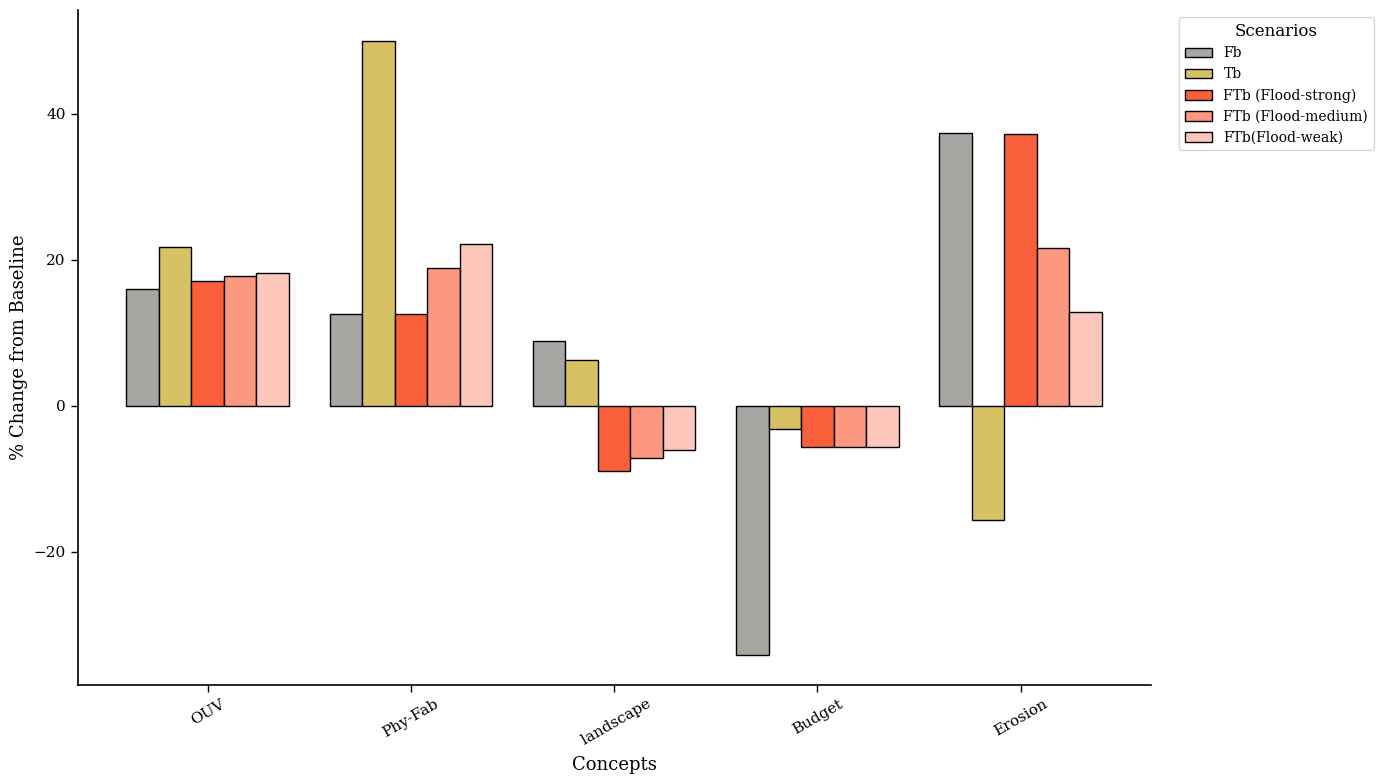

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from fcmpy import FcmSimulator
import os

# =========================
# File paths
# =========================
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_folder = "Results"
os.makedirs(output_folder, exist_ok=True)

# =========================
# GLOBAL PUBLICATION STYLE
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})

# =========================
# Load FCM adjacency matrix
# =========================
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# =========================
# Load concept labels
# =========================
labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# =========================
# Load initial values
# =========================
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept_label_map.get(cid, cid): float(
            df.loc[df['Concept ID'] == cid, 'Initial Value'].values[0]
        ) if cid in df['Concept ID'].values else 0.0
        for cid in concept_ids
    }

init_state = get_initial_values()
sim = FcmSimulator()

# =========================
# Simulation function
# =========================
def simulate_fcm(initial_state, weight_matrix, iterations=20):
    mod_matrix = weight_matrix.copy()
    inactive = [c for c, v in initial_state.items() if float(v) == 0.0]

    for c in inactive:
        if c in concept_labels:
            idx = concept_labels.index(c)
            mod_matrix[:, idx] = 0
            mod_matrix[idx, :] = 0

    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=mod_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=iterations,
        l=1
    )

# =========================
# Baseline simulation
# =========================
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concept_labels)
last_values = baseline_df.iloc[-1].to_dict()

# =========================
# Interventions
# =========================
def apply_intervention(name, base_state):
    state = base_state.copy()

    if name == "flood_with_management_response_(Fb)":
        state.update({
            concept_label_map['C15']: 1.0,
            concept_label_map['C11']: 1.0,
            concept_label_map['C39']: 0.25,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    elif name == "tourism_with_management_response_(Tb)":
        state.update({
            concept_label_map['C40']: 1.0,
            concept_label_map['C21']: 0.1,
            concept_label_map['C39']: 0.25,
            concept_label_map['C28']: 0.1
        })

    elif name == "combined_FTb_flood_1.0":
        state.update({
            concept_label_map['C15']: 1.0,
            concept_label_map['C11']: 1.0,
            concept_label_map['C40']: 0.5,
            concept_label_map['C39']: 0.25,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    elif name == "combined_FTb_flood_0.5":
        state.update({
            concept_label_map['C15']: 0.5,
            concept_label_map['C11']: 0.5,
            concept_label_map['C40']: 0.5,
            concept_label_map['C39']: 0.25,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    elif name == "combined_FTb_flood_0.25":
        state.update({
            concept_label_map['C15']: 0.25,
            concept_label_map['C11']: 0.25,
            concept_label_map['C40']: 0.5,
            concept_label_map['C39']: 0.25,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1.0,
            concept_label_map['C28']: 0.1
        })

    return state

# =========================
# Scenarios
# =========================
scenarios = {
    "Baseline": last_values,
    "Fb": apply_intervention("flood_with_management_response_(Fb)", last_values),
    "Tb": apply_intervention("tourism_with_management_response_(Tb)", last_values),
    "FTb (Flood-strong)": apply_intervention("combined_FTb_flood_1.0", last_values),
    "FTb (Flood-medium)": apply_intervention("combined_FTb_flood_0.5", last_values),
    "FTb(Flood-weak)": apply_intervention("combined_FTb_flood_0.25", last_values)
}

# =========================
# Target concepts
# =========================
target_concepts = ["C1", "C2", "C3", "C7", "C8"]
target_labels = [concept_label_map[cid] for cid in target_concepts]

# =========================
# Run scenarios
# =========================
final_table = pd.DataFrame()
percentage_table = pd.DataFrame()

baseline_final = baseline_df.iloc[-1][target_labels]

for name, state in scenarios.items():
    result = simulate_fcm(state, weight_matrix)
    df_result = pd.DataFrame(result, columns=concept_labels)

    final_values = df_result.iloc[-1][target_labels]
    final_table.loc[name, target_labels] = final_values.values

    pct_change = ((final_values - baseline_final) / baseline_final * 100)\
        .replace([np.inf, -np.inf], 0).fillna(0)
    percentage_table.loc[name, target_labels] = pct_change.values

percentage_table_no_baseline = percentage_table.drop("Baseline")

# =========================
# Colors
# =========================
def lighten_color(color, amount):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

scenario_colors = {
    "Fb": "#a8a6a3",
    "Tb": "#d6c165",
    "FTb (Flood-strong)": "#fa5f3c",
    "FTb (Flood-medium)": lighten_color("#fa5f3c", 0.35),
    "FTb(Flood-weak)": lighten_color("#fa5f3c", 0.65),
}

# =========================
# Plot (publication style)
# =========================
plt.figure(figsize=(14, 8))

x = np.arange(len(target_labels))
num_scenarios = len(percentage_table_no_baseline)
total_width = 0.8
bar_width = total_width / num_scenarios

offsets = np.linspace(
    -total_width / 2 + bar_width / 2,
    total_width / 2 - bar_width / 2,
    num_scenarios
)

for i, scenario in enumerate(percentage_table_no_baseline.index):
    plt.bar(
        x + offsets[i],
        percentage_table_no_baseline.loc[scenario],
        width=bar_width,
        color=scenario_colors[scenario],
        label=scenario,
        edgecolor="black"
    )

plt.xticks(x, target_labels, rotation=30)
plt.xlabel("Concepts")
plt.ylabel("% Change from Baseline")

# Clean axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(direction='out', length=5, width=1)

plt.legend(title="Scenarios", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(False)
plt.tight_layout()

# =========================
# Save figure
# =========================
png_path = os.path.join(output_folder, "Comparison_with Usage_Baseline.png")
pdf_path = os.path.join(output_folder, "Comparison_with Usage_Baseline.pdf")

plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

plt.show()